# 05 XGBoost Demand Model

## Goal
Train an XGBoost model to predict department-level demand and compare it with the Random Forest baseline.

## Input
`data/processed_demand_data.csv`

## Notes
The model is trained on `log_demand` and predictions are converted back to real demand.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [3]:
demand_data = pd.read_csv("/Users/ayu/Desktop/AI_Grocery_Demand_Forecasting/notebooks/data/processed_demand_data.csv")
demand_data.head()

,day_of_week,hour,dept_name,demand,is_weekend,hour_sin,hour_cos,dept_encoded,log_demand
0,0,0,alcohol,52,1,0.0,1.0,0,3.970292
1,0,0,babies,400,1,0.0,1.0,1,5.993961
2,0,0,bakery,1301,1,0.0,1.0,2,7.171657
3,0,0,beverages,2970,1,0.0,1.0,3,7.996654
4,0,0,breakfast,721,1,0.0,1.0,4,6.582025


## 1. Define Features and Target

In [4]:
X = demand_data[['day_of_week', 'hour', 'is_weekend', 'hour_sin', 'hour_cos', 'dept_encoded']]
y = demand_data['log_demand']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2822, 6)
X_test shape: (706, 6)


## 2. Train XGBoost Model

In [6]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 3. Predict and Convert Back to Real Demand

In [7]:
log_predictions = xgb_model.predict(X_test)

predictions = np.expm1(log_predictions)
actual = np.expm1(y_test)

## 4. Evaluate Model

In [8]:
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("XGBoost MAE:", mae)
print("XGBoost RMSE:", rmse)

XGBoost MAE: 522.9958373196732
XGBoost RMSE: 1555.050814461561


## 5. Feature Importance

In [9]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
1,hour,0.476431
5,dept_encoded,0.381311
4,hour_cos,0.112241
3,hour_sin,0.019708
2,is_weekend,0.005339
0,day_of_week,0.004970


## 6. Actual vs Predicted Demand

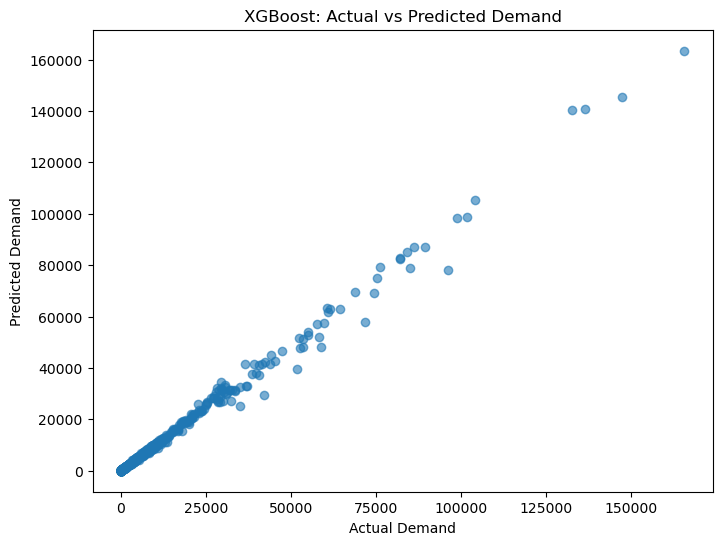

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(actual, predictions, alpha=0.6)
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("XGBoost: Actual vs Predicted Demand")
plt.show()

## 7. Residual Analysis

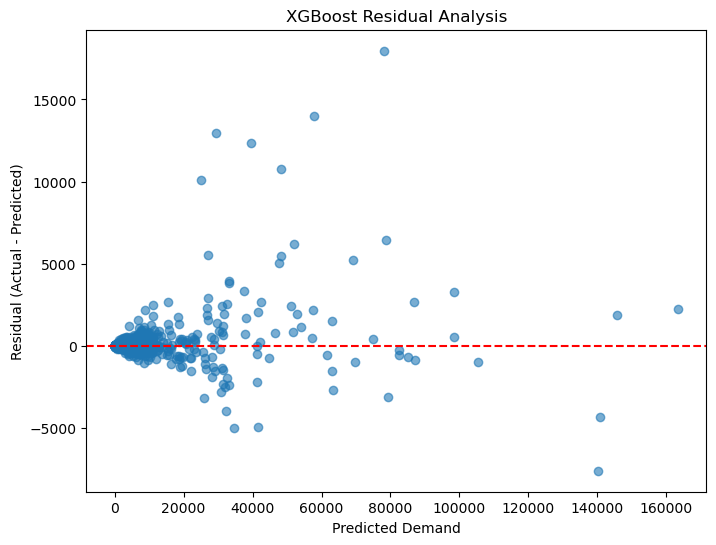

In [11]:
residuals = actual - predictions

plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Demand")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("XGBoost Residual Analysis")
plt.show()

## 8. Scenario Prediction Function
Use the trained model to forecast demand for a specific department and hour.

In [12]:
def predict_demand(day_of_week, hour, dept_encoded):
    is_weekend = 1 if day_of_week in [0, 6] else 0
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    input_data = pd.DataFrame({
        'day_of_week': [day_of_week],
        'hour': [hour],
        'is_weekend': [is_weekend],
        'hour_sin': [hour_sin],
        'hour_cos': [hour_cos],
        'dept_encoded': [dept_encoded]
    })

    log_prediction = xgb_model.predict(input_data)
    demand_prediction = np.expm1(log_prediction)

    return demand_prediction[0]

In [13]:
dept_mapping = demand_data[['dept_name', 'dept_encoded']].drop_duplicates().sort_values('dept_encoded')
dept_mapping

,dept_name,dept_encoded
0,alcohol,0
1,babies,1
2,bakery,2
3,beverages,3
4,breakfast,4
5,bulk,5
6,canned goods,6
7,dairy eggs,7
8,deli,8
9,dry goods pasta,9


In [14]:
# Example: Saturday, 10 AM, Produce
predict_demand(day_of_week=6, hour=10, dept_encoded=19)

109112.66

## Key Takeaways
- XGBoost improves forecasting accuracy over the Random Forest baseline.
- Time of day and department are the strongest demand drivers.
- The model can be used for operational scenario planning.

## Next notebook
`06_prophet_forecasting.ipynb`